In [10]:
import pandas as pd

In [11]:
df=pd.read_csv("/content/KDDTest+.txt")
df.shape

(6868, 43)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display
from sklearn.preprocessing import MinMaxScaler

In [13]:
df=pd.read_csv("/content/KDDTest+.txt")

In [14]:
cols= (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
df.columns = cols[:len(df.columns)]

In [15]:
print("Number of rows:",len(df))
print("Unique labels:",df['level'].nunique())
print("Top 5 frequent attack types:\n", df['level'].value_counts().head())

Number of rows: 13734
Unique labels: 22
Top 5 frequent attack types:
 level
21.0    6478
18.0    1818
20.0     861
15.0     735
17.0     694
Name: count, dtype: int64


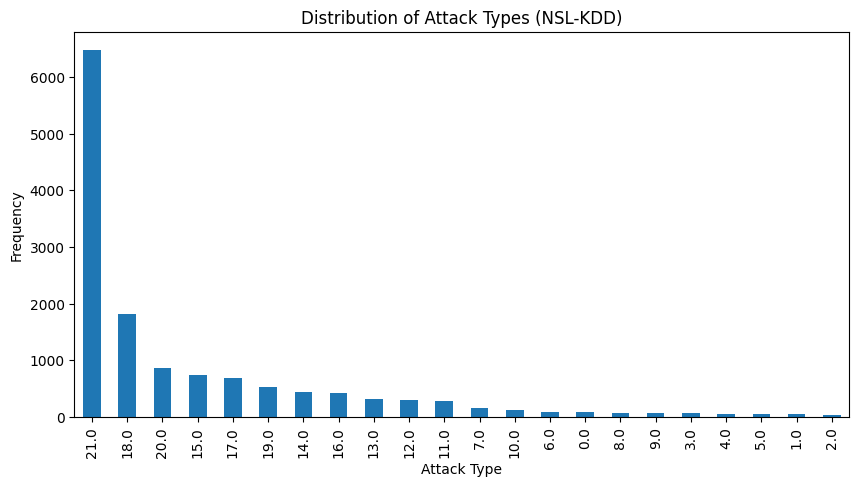

In [16]:
df['level'].value_counts().plot(kind='bar',figsize=(10,5))
plt.title("Distribution of Attack Types (NSL-KDD)")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13734 entries, 0 to 13733
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     13734 non-null  int64  
 1   protocol_type                13734 non-null  object 
 2   service                      13734 non-null  object 
 3   flag                         13734 non-null  object 
 4   src_bytes                    13734 non-null  int64  
 5   dst_bytes                    13734 non-null  int64  
 6   land                         13734 non-null  int64  
 7   wrong_fragment               13734 non-null  int64  
 8   urgent                       13734 non-null  int64  
 9   hot                          13734 non-null  int64  
 10  num_failed_logins            13734 non-null  int64  
 11  logged_in                    13734 non-null  int64  
 12  num_compromised              13734 non-null  int64  
 13  root_shell      

In [18]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21.0
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21.0
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15.0
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11.0
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21.0


In [19]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,13734.000000,1.373400e+04,1.373400e+04,13734.000000,13734.000000,13734.000000,13734.000000,13734.000000,13734.000000,13734.000000,...,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000,13733.000000
mean,216.133392,1.036892e+04,2.086021e+03,0.000146,0.006844,0.000947,0.107471,0.021625,0.445537,0.171254,...,141.184155,0.609252,0.089396,0.133441,0.019359,0.096315,0.098577,0.232471,0.224118,18.022937
std,1327.352166,5.379387e+05,2.196241e+04,0.012067,0.122879,0.042656,1.034868,0.148924,0.497043,9.282429,...,111.696550,0.434904,0.218195,0.306804,0.083739,0.270650,0.280806,0.386275,0.399466,4.256896
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.600000e+01,4.800000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,169.000000,0.920000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.910000e+02,6.157500e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.350000,0.140000,21.000000
max,54451.000000,6.282565e+07,1.288652e+06,1.000000,3.000000,3.000000,101.000000,3.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


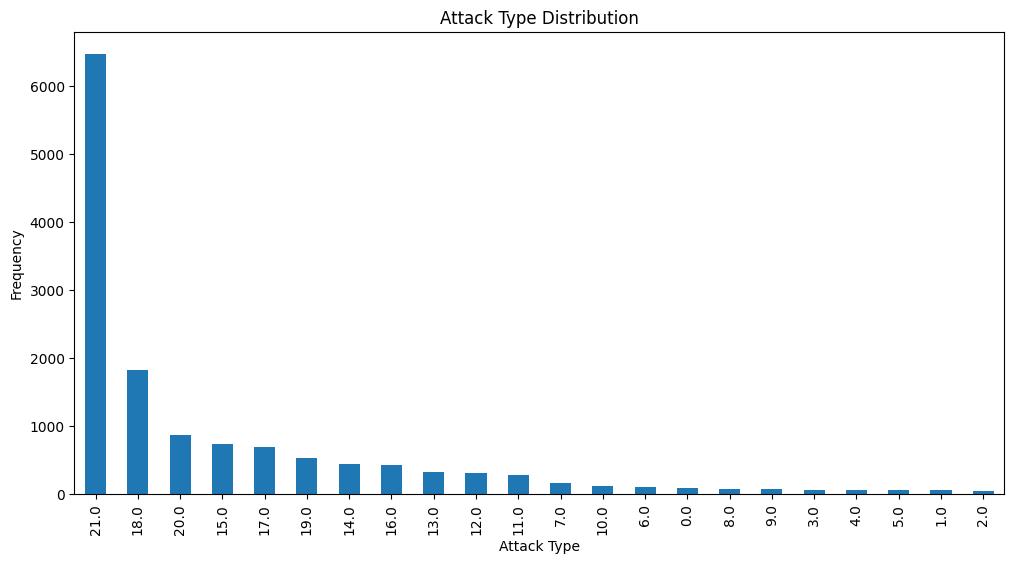

In [20]:
df['level'].value_counts().plot(kind='bar',figsize=(12,6))
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.show()

In [21]:
print("Missing values ")
print(df.isnull().sum())
print("\n Duplicate Rows :", df.duplicated().sum())

Missing values 
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate              

In [22]:
data=df.fillna(0)
data=data.drop_duplicates()

In [23]:
categorical=["protocol_type","service","flag"]
binary=["land","logged_in","root_shell","su_attempted","is_host_login","is_guest_login"]
numerical=[col for col in df.columns if col not in categorical+binary+['level']]
print("Categorical features:",categorical)
print("Binary features:",binary)
print("Numerical features (first 10):", numerical[:10])

Categorical features: ['protocol_type', 'service', 'flag']
Binary features: ['land', 'logged_in', 'root_shell', 'su_attempted', 'is_host_login', 'is_guest_login']
Numerical features (first 10): ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'num_root', 'num_file_creations']


In [24]:
scaler=MinMaxScaler()
numerical = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical]=scaler.fit_transform(df[numerical])
numerical_data=df[numerical].head()
print("Data after normalization:\n", numerical_data)

Data after normalization:
    duration     src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0  0.000000  0.000000e+00   0.000000   0.0             0.0     0.0  0.0   
1  0.000037  2.066513e-04   0.000000   0.0             0.0     0.0  0.0   
2  0.000000  3.183413e-07   0.000000   0.0             0.0     0.0  0.0   
3  0.000018  0.000000e+00   0.000012   0.0             0.0     0.0  0.0   
4  0.000000  4.249857e-06   0.011264   0.0             0.0     0.0  0.0   

   num_failed_logins  logged_in  num_compromised  ...  dst_host_srv_count  \
0                0.0        0.0              0.0  ...            0.003922   
1                0.0        0.0              0.0  ...            0.337255   
2                0.0        0.0              0.0  ...            0.223529   
3                0.0        0.0              0.0  ...            0.337255   
4                0.0        1.0              0.0  ...            1.000000   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0     

In [25]:
data=pd.get_dummies(data,columns=categorical)
print("\n Data after one-hot encoding\n",data.head())


 Data after one-hoting
    duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0         0          0          0     0               0       0    0   
1         2      12983          0     0               0       0    0   
2         0         20          0     0               0       0    0   
3         1          0         15     0               0       0    0   
4         0        267      14515     0               0       0    0   

   num_failed_logins  logged_in  num_compromised  ...  flag_REJ  flag_RSTO  \
0                  0          0                0  ...      True      False   
1                  0          0                0  ...     False      False   
2                  0          0                0  ...     False      False   
3                  0          0                0  ...     False       True   
4                  0          1                0  ...     False      False   

   flag_RSTOS0  flag_RSTR  flag_S0  flag_S1  flag_S2  flag_S3  flag_SF  \

In [26]:
encoded_columns = [col for col in data.columns if col.startswith('protocol_type_')
                   or col.startswith('service_')
                   or col.startswith('flag_')]

print("Encoded columns:")
print(data[encoded_columns].head())

Encoded columns:
   protocol_type_icmp  protocol_type_tcp  protocol_type_udp  service_IRC  \
0               False               True              False        False   
1               False               True              False        False   
2                True              False              False        False   
3               False               True              False        False   
4               False               True              False        False   

   service_X11  service_Z39_50  service_auth  service_bgp  service_courier  \
0        False           False         False        False            False   
1        False           False         False        False            False   
2        False           False         False        False            False   
3        False           False         False        False            False   
4        False           False         False        False            False   

   service_csnet_ns  ...  flag_REJ  flag_RSTO  flag_RSTOS

In [39]:
x=data.drop(columns=['outcome', 'level'])
y=data['outcome']

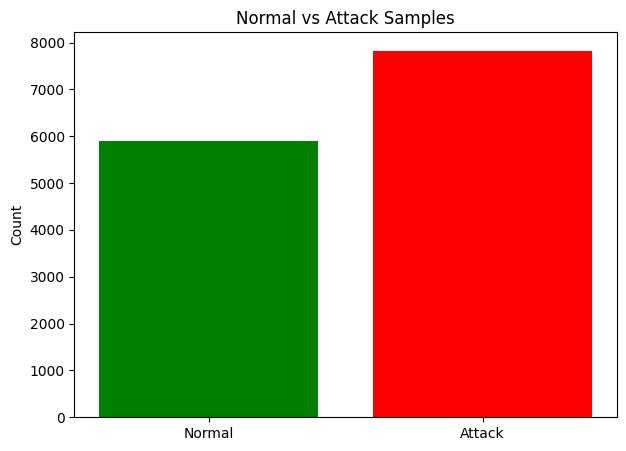

In [40]:
y=y.apply(lambda val: 0 if val=='normal' else 1)
nrml_count = (y == 0).sum()
attack_count = (y == 1).sum()
plt.figure(figsize=(7, 5))
plt.bar(['Normal', 'Attack'], [nrml_count, attack_count], color=['green', 'red'])
plt.title('Normal vs Attack Samples')
plt.ylabel('Count')
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
# Train the model
model=LogisticRegression()
model.fit(x_train,y_train)
# Make predictions
y_pred=model.predict(x_test)
# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))
print("\nAccuracy:", accuracy_score(y_test,y_pred))

Confusion Matrix:
 [[1551  221]
 [ 484 1865]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.88      0.81      1772
           1       0.89      0.79      0.84      2349

    accuracy                           0.83      4121
   macro avg       0.83      0.83      0.83      4121
weighted avg       0.84      0.83      0.83      4121


Accuracy: 0.8289250181994662


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
